# unsubmit 因子批量回测绩效统计

- 回测区间：`2024-01-01` ~ `2026-09-01`（信号窗口）
- 调仓周期：1 天；分组数：5
- 费率：0.0005；滑点：0.001；含资金费：True
- 因子由分钟频框架批量转换为 `factor_common` 日频契约（`TYPE`/`META`/`SETTING`/`calc_factor`），截面去极值与秩归一化由框架 `mad_rank` 完成
- 字段映射：`dollar_volume`/`turnover`/`xbinance_quote_volume` → `quote_volume`，`xbinance_taker_buy_quote_volume` → `taker_buy_quote_volume`，`xbinance_trade_count` → `trade_count`，`funding` → 日频平均资金费率
- 数据源：`data/crypto_quant.h5`（point-in-time top50 宇宙）
- 每个因子的完整 HTML 报告见 `reports/<factor>.html`

> 注意：受 H5 资金费覆盖限制，`all_costs` 场景在真实数据上通常无法完整认证（status=incomplete），此时以 `trading_net`（含手续费+滑点）作为净绩效参考。分钟级滚动窗口已按公式意图改写为日频等价形式，语义判断记录在各因子模块 docstring。

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = Path('../outputs/unsubmit_results.json')
payload = json.loads(RESULTS_PATH.read_text())
rows = payload['results']
df = pd.DataFrame(rows)
print(f"factors: {len(df)}, params: {payload['params']}")
df['status'].value_counts().to_frame('count')

factors: 87, params: {'start': '2024-01-01', 'end': '2026-09-01', 'rebalance_days': 1, 'n_groups': 5, 'fee_rate': 0.0005, 'slippage': 0.001, 'include_funding': True}


,count
status,
complete,77
skipped,10


## 1. 总览：IC 指标（全样本 full）

按 `rank_ic_mean` 降序。`icir` 未年化；`t_stat`/`p_value` 为 IC 序列显著性。
`static_scan`/`cutoff` 为未来函数检查结论（静态扫描 + 截断重放一致性）。

In [2]:
ic_cols = ['factor', 'status', 'full.rank_ic_mean', 'full.ic_mean', 'full.icir',
           'full.t_stat', 'full.p_value', 'static_scan', 'cutoff']
ic_table = (df[ic_cols]
            .sort_values('full.rank_ic_mean', ascending=False, na_position='last')
            .reset_index(drop=True))
ic_table.index += 1
ic_table.style.format({c: '{:.4f}' for c in ic_cols if c.startswith('full.')},
                      na_rep='-')

,factor,status,full.rank_ic_mean,full.ic_mean,full.icir,full.t_stat,full.p_value,static_scan,cutoff
1,crypto_alpha_range_level_premium_20d,complete,0.0813,0.0406,0.1393,4.3463,0.0000,clean,verified
2,crypto_alpha_volume_convergence_factor,complete,0.0435,0.0261,0.1387,4.3288,0.0000,clean,verified
3,crypto_alpha_010,complete,0.0351,0.0199,0.1186,3.7007,0.0002,clean,verified
4,crypto_alpha_pv_corr_premium_10d,complete,0.0307,0.0064,0.0347,1.0826,0.2793,clean,verified
5,crypto_alpha_close_location_premium_20d,complete,0.0280,0.0205,0.1015,3.1665,0.0016,clean,verified
6,crypto_alpha_high_amplitude_excess_momentum_2,complete,0.0269,0.0040,0.0191,0.5954,0.5517,clean,verified
7,crypto_alpha_activity_burst_premium_20d,complete,0.0245,0.0076,0.0420,1.3099,0.1905,clean,verified
8,crypto_alpha_001,complete,0.0236,0.0005,0.0036,0.1133,0.9098,clean,verified
9,crypto_alpha_005,complete,0.0206,0.0075,0.0442,1.3783,0.1684,clean,verified
10,crypto_alpha_taker_buy_ratio_persist10,complete,0.0201,0.0224,0.1205,3.7612,0.0002,clean,verified


## 2. RankIC 分布图

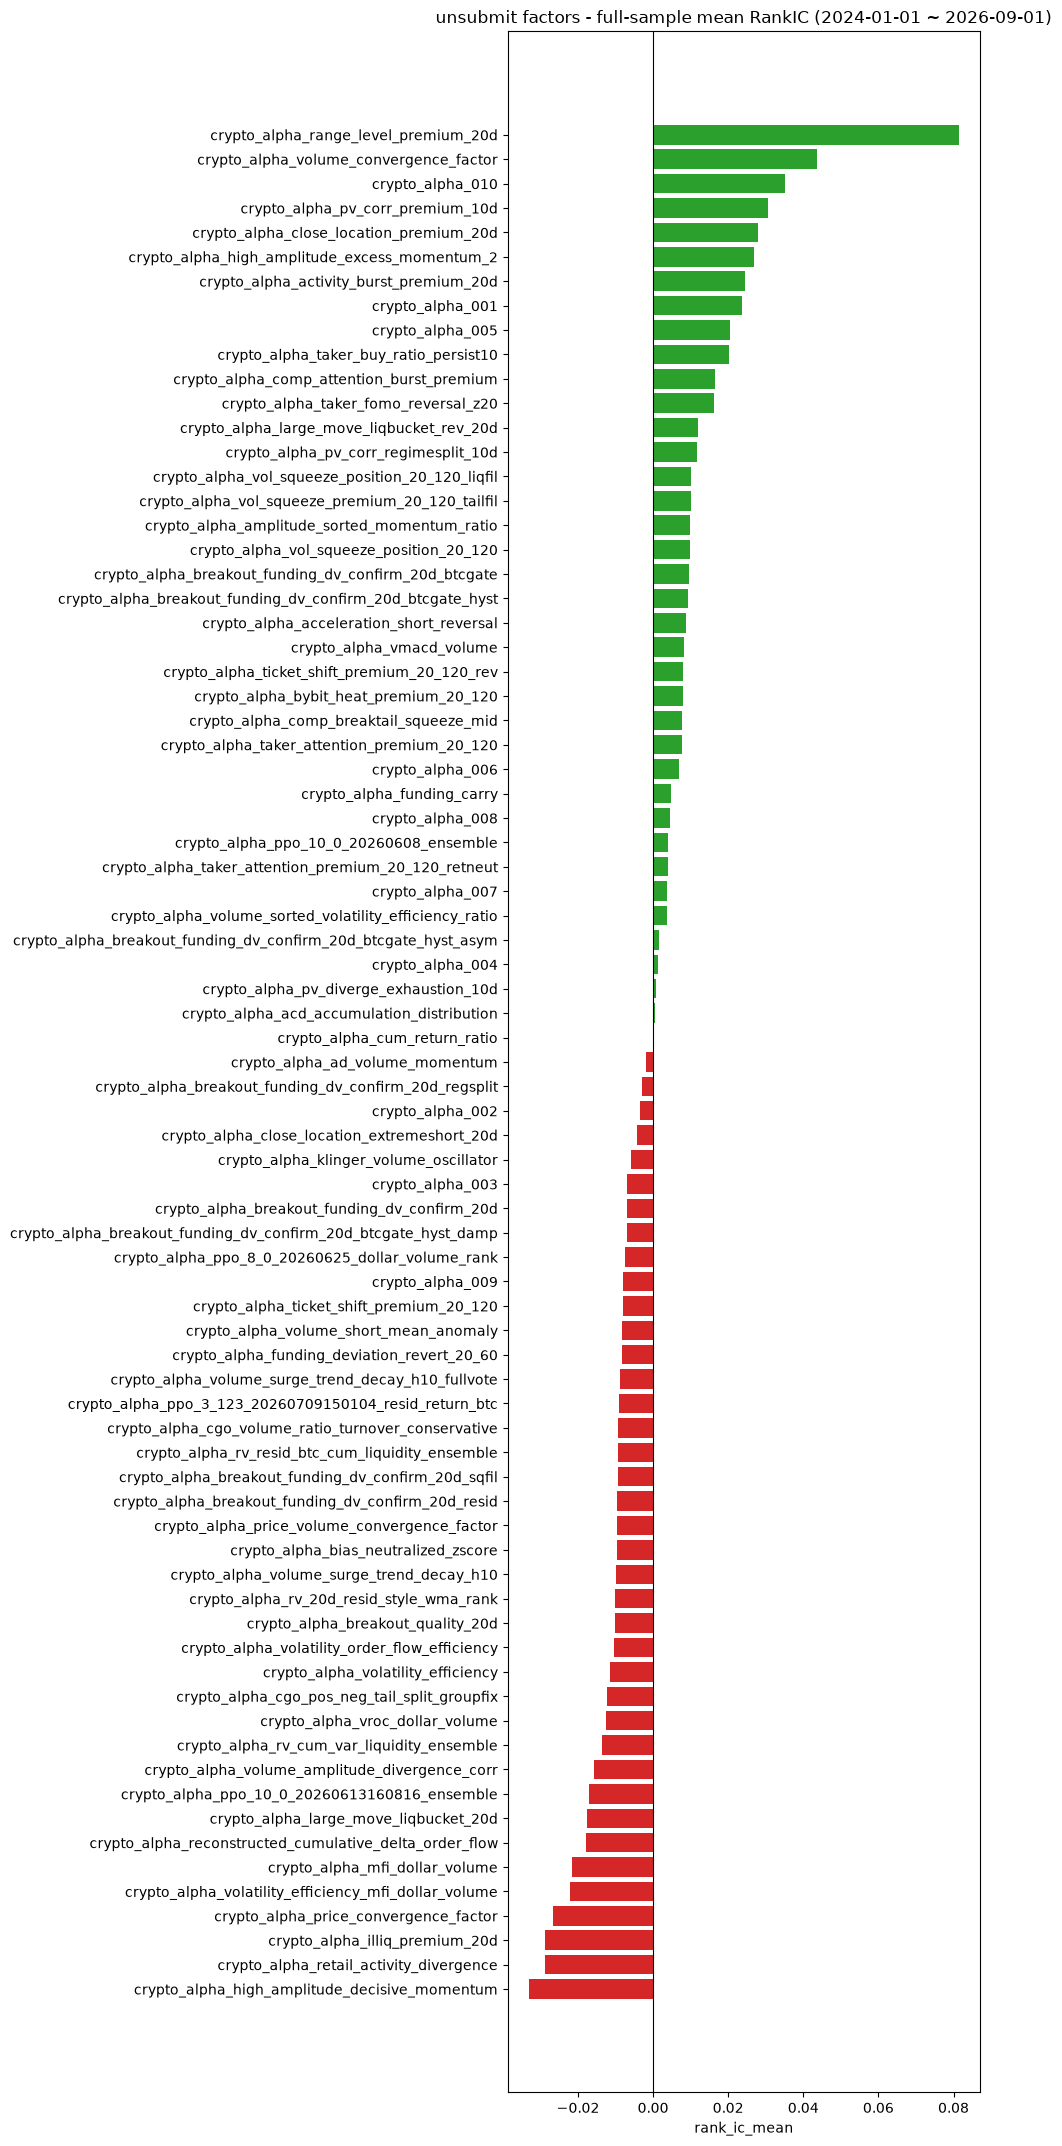

In [3]:
plot_df = df.dropna(subset=['full.rank_ic_mean']).sort_values('full.rank_ic_mean')
fig, ax = plt.subplots(figsize=(10, max(8, 0.28 * len(plot_df))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['full.rank_ic_mean']]
ax.barh(plot_df['factor'], plot_df['full.rank_ic_mean'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('unsubmit factors - full-sample mean RankIC (2024-01-01 ~ 2026-09-01)')
ax.set_xlabel('rank_ic_mean')
plt.tight_layout()
plt.show()

## 3. 样本内 / 样本外 IC 稳定性

样本外 = 最后 180 天。`rank_ic_oos` 与全样本符号一致且幅度未大幅衰减的因子更稳健。

In [4]:
split_cols = ['factor', 'full.rank_ic_mean', 'in_sample.rank_ic_mean',
              'out_of_sample.rank_ic_mean', 'in_sample.t_stat', 'out_of_sample.t_stat']
split_table = (df[split_cols]
               .sort_values('full.rank_ic_mean', ascending=False, na_position='last')
               .reset_index(drop=True))
split_table.index += 1
split_table.style.format({c: '{:.4f}' for c in split_cols if c != 'factor'}, na_rep='-')

,factor,full.rank_ic_mean,in_sample.rank_ic_mean,out_of_sample.rank_ic_mean,in_sample.t_stat,out_of_sample.t_stat
1,crypto_alpha_range_level_premium_20d,0.0813,0.0837,0.0708,4.0997,1.4534
2,crypto_alpha_volume_convergence_factor,0.0435,0.0429,0.0449,3.6904,2.3269
3,crypto_alpha_010,0.0351,0.0355,0.0332,3.3987,1.4170
4,crypto_alpha_pv_corr_premium_10d,0.0307,0.0302,0.0329,0.9585,0.4513
5,crypto_alpha_close_location_premium_20d,0.0280,0.0286,0.0245,2.9404,1.1073
6,crypto_alpha_high_amplitude_excess_momentum_2,0.0269,0.0258,0.0322,0.8107,-0.3551
7,crypto_alpha_activity_burst_premium_20d,0.0245,0.0191,0.0470,0.6206,1.7490
8,crypto_alpha_001,0.0236,0.0231,0.0260,0.1571,-0.1167
9,crypto_alpha_005,0.0206,0.0215,0.0173,1.3385,0.4438
10,crypto_alpha_taker_buy_ratio_persist10,0.0201,0.0201,0.0198,3.3406,1.6583


## 4. 多空组合绩效（trading_net = 含手续费+滑点）

`gross` 为无成本对照。收益为复利累计；`max_drawdown` 为复合 NAV 上的最大回撤（小数）。

In [5]:
perf_cols = ['factor', 'trading_net.sharpe', 'trading_net.total_return',
             'trading_net.annual_return', 'trading_net.max_drawdown',
             'trading_net.win_rate', 'gross.sharpe', 'gross.total_return']
perf_table = (df[perf_cols]
              .sort_values('trading_net.sharpe', ascending=False, na_position='last')
              .reset_index(drop=True))
perf_table.index += 1
perf_table.style.format({c: '{:.3f}' for c in perf_cols if c != 'factor'}, na_rep='-')

,factor,trading_net.sharpe,trading_net.total_return,trading_net.annual_return,trading_net.max_drawdown,trading_net.win_rate,gross.sharpe,gross.total_return
1,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst,1.084,0.548,0.179,0.180,0.300,1.742,1.057
2,crypto_alpha_bias_neutralized_zscore,0.950,0.685,0.216,0.220,0.536,1.753,1.779
3,crypto_alpha_range_level_premium_20d,0.798,0.654,0.207,0.265,0.549,1.073,1.044
4,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate,0.710,0.309,0.106,0.177,0.274,1.553,0.871
5,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst_asym,0.431,0.202,0.071,0.219,0.510,1.486,1.172
6,crypto_alpha_taker_buy_ratio_persist10,0.420,0.194,0.069,0.267,0.529,1.368,1.041
7,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst_damp,0.399,0.184,0.066,0.223,0.522,1.080,0.762
8,crypto_alpha_breakout_funding_dv_confirm_20d,0.399,0.184,0.066,0.223,0.522,1.080,0.762
9,crypto_alpha_breakout_funding_dv_confirm_20d_resid,0.340,0.143,0.052,0.222,0.525,1.024,0.699
10,crypto_alpha_breakout_quality_20d,0.334,0.144,0.052,0.276,0.524,1.687,1.607


## 5. 净 Sharpe 分布图

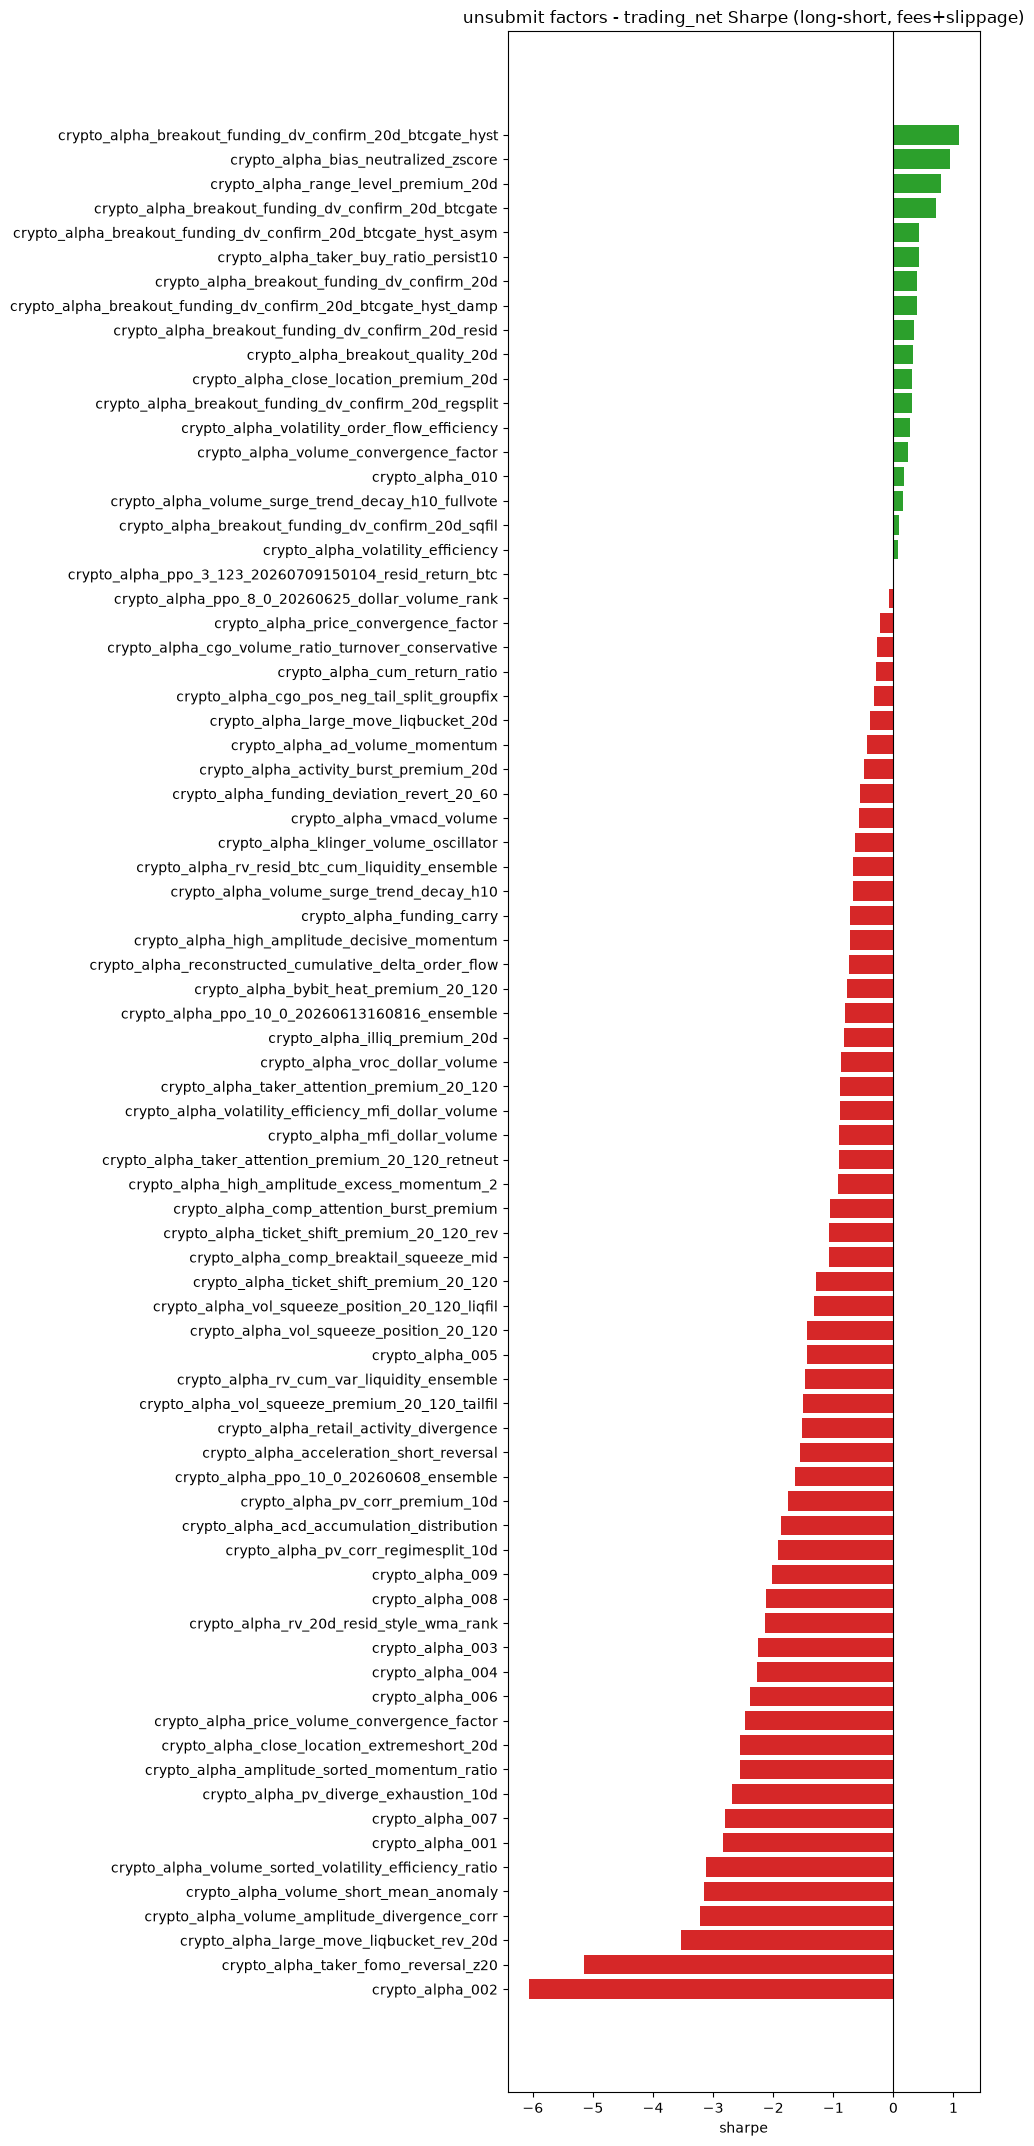

In [6]:
plot_df = df.dropna(subset=['trading_net.sharpe']).sort_values('trading_net.sharpe')
fig, ax = plt.subplots(figsize=(10, max(8, 0.28 * len(plot_df))))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df['trading_net.sharpe']]
ax.barh(plot_df['factor'], plot_df['trading_net.sharpe'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('unsubmit factors - trading_net Sharpe (long-short, fees+slippage)')
ax.set_xlabel('sharpe')
plt.tight_layout()
plt.show()

## 6. 筛选：可进一步研究的因子

标准：全样本 `|rank_ic_mean| >= 0.02` 且 `|t_stat| >= 2`，且样本外 rank_ic 与全样本同号。
按 `|rank_ic_mean|` 降序。

In [7]:
mask = ((df['full.rank_ic_mean'].abs() >= 0.02)
        & (df['full.t_stat'].abs() >= 2)
        & (df['out_of_sample.rank_ic_mean'] * df['full.rank_ic_mean'] > 0))
selected = (df.loc[mask, ['factor', 'full.rank_ic_mean', 'full.t_stat',
                          'in_sample.rank_ic_mean', 'out_of_sample.rank_ic_mean',
                          'trading_net.sharpe', 'trading_net.total_return',
                          'trading_net.max_drawdown']]
            .assign(abs_rank_ic=lambda x: x['full.rank_ic_mean'].abs())
            .sort_values('abs_rank_ic', ascending=False)
            .drop(columns='abs_rank_ic')
            .reset_index(drop=True))
selected.index += 1
print(f'selected: {len(selected)} / {len(df)}')
selected.style.format({c: '{:.4f}' for c in selected.columns if c != 'factor'}, na_rep='-')

selected: 8 / 87


,factor,full.rank_ic_mean,full.t_stat,in_sample.rank_ic_mean,out_of_sample.rank_ic_mean,trading_net.sharpe,trading_net.total_return,trading_net.max_drawdown
1,crypto_alpha_range_level_premium_20d,0.0813,4.3463,0.0837,0.0708,0.7977,0.6539,0.2654
2,crypto_alpha_volume_convergence_factor,0.0435,4.3288,0.0429,0.0449,0.2404,0.0781,0.4217
3,crypto_alpha_010,0.0351,3.7007,0.0355,0.0332,0.1769,0.0425,0.3029
4,crypto_alpha_retail_activity_divergence,-0.0289,-2.0798,-0.0336,-0.0088,-1.5166,-0.5618,0.5785
5,crypto_alpha_illiq_premium_20d,-0.0287,-2.7178,-0.0269,-0.0380,-0.8298,-0.3649,0.4326
6,crypto_alpha_close_location_premium_20d,0.0280,3.1665,0.0286,0.0245,0.3147,0.1302,0.2730
7,crypto_alpha_price_convergence_factor,-0.0266,-2.8971,-0.0278,-0.0211,-0.2299,-0.1325,0.3396
8,crypto_alpha_taker_buy_ratio_persist10,0.0201,3.7612,0.0201,0.0198,0.4196,0.1942,0.2669


## 7. 跳过 / 失败因子

`skipped` = 依赖日频 H5 未提供的数据（open_interest、mark/index_close、bybit standards、跨交易所份额），未做转换；其余为评估异常。

In [8]:
bad = df[~df['status'].isin(['complete', 'incomplete'])]
if bad.empty:
    print('无跳过/失败因子')
else:
    display(bad[['factor', 'status', 'error']].reset_index(drop=True))

,factor,status,error
0,crypto_alpha_basis_meanrev_1d,skipped,需要 mark_close/index_close（日频 H5 未提供）
1,crypto_alpha_bybit_heat_standard_tier_20_120,skipped,需要 bybit standards 分级数据（日频 H5 未提供）
2,crypto_alpha_comp_attention_burst_oi,skipped,需要 open_interest（日频 H5 未提供）
3,crypto_alpha_comp_attention_oi_buildup,skipped,需要 open_interest（日频 H5 未提供）
4,crypto_alpha_comp_oi_buildup_chase_int,skipped,需要 open_interest/mark_close（日频 H5 未提供）
5,crypto_alpha_oi_buildup_premium_20_120,skipped,需要 open_interest（日频 H5 未提供）
6,crypto_alpha_oi_buildup_premium_20_120_longfil,skipped,需要 open_interest（日频 H5 未提供）
7,crypto_alpha_oi_chase_intensity_premium_5d,skipped,需要 open_interest/mark_close（日频 H5 未提供）
8,crypto_alpha_oi_chase_reversal_5d,skipped,需要 open_interest/mark_close（日频 H5 未提供）
9,crypto_alpha_venue_share_shift_20_120,skipped,跨交易所份额（bybit/binance），日频仅 binance 数据，份额退化为常数


## 8. all_costs 总绩效（含手续费+滑点+资金费）

按 `all_costs.annual_return` 降序。与第 4 节的 `trading_net` 相比，`all_costs` 额外计入了资金费现金流；`cost_drag` = gross − all_costs 年收益差。

In [9]:
ac_cols = ['factor', 'all_costs.annual_return', 'all_costs.total_return',
         'all_costs.sharpe', 'all_costs.max_drawdown', 'all_costs.win_rate',
         'gross.annual_return']
ac_table = (df.dropna(subset=['all_costs.annual_return'])[ac_cols]
            .assign(cost_drag=lambda x: x['gross.annual_return'] - x['all_costs.annual_return'])
            .sort_values('all_costs.annual_return', ascending=False)
            .reset_index(drop=True))
ac_table.index += 1
ac_table.style.format({c: '{:.3f}' for c in ac_table.columns if c != 'factor'}, na_rep='-')

,factor,all_costs.annual_return,all_costs.total_return,all_costs.sharpe,all_costs.max_drawdown,all_costs.win_rate,gross.annual_return,cost_drag
1,crypto_alpha_bias_neutralized_zscore,0.233,0.749,1.009,0.202,0.539,0.466,0.233
2,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst,0.160,0.482,0.985,0.200,0.294,0.311,0.152
3,crypto_alpha_range_level_premium_20d,0.151,0.455,0.631,0.271,0.544,0.307,0.156
4,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate,0.089,0.254,0.610,0.196,0.269,0.265,0.177
5,crypto_alpha_taker_buy_ratio_persist10,0.052,0.144,0.343,0.284,0.524,0.306,0.255
6,crypto_alpha_breakout_quality_20d,0.051,0.143,0.333,0.277,0.530,0.431,0.380
7,crypto_alpha_volume_surge_trend_decay_h10_fullvote,0.049,0.135,0.331,0.408,0.526,0.094,0.046
8,crypto_alpha_volatility_order_flow_efficiency,0.043,0.118,0.297,0.243,0.517,0.360,0.318
9,crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst_damp,0.039,0.106,0.283,0.231,0.515,0.237,0.199
10,crypto_alpha_breakout_funding_dv_confirm_20d,0.039,0.106,0.283,0.231,0.515,0.237,0.199


## 9. all_costs 分年度绩效

从 `reports/<factor>.html` 内嵌的 all_costs NAV 序列复合出每年收益（2026 年为年初至今）。先给全库分年度透视表（按全样本 all_costs 年收益排序），再给按年份的横截面汇总。

In [10]:
import re

def _matched_json_array(text, start_at):
    start = text.find('[', start_at)
    if start < 0:
        raise ValueError('NAV data array not found')
    depth, quoted, escaped = 0, False, False
    for index in range(start, len(text)):
        char = text[index]
        if quoted:
            if escaped:
                escaped = False
            elif char == '\\':
                escaped = True
            elif char == '"':
                quoted = False
        else:
            if char == '"':
                quoted = True
            elif char == '[':
                depth += 1
            elif char == ']':
                depth -= 1
                if depth == 0:
                    return text[start:index + 1]
    raise ValueError('NAV data array is not closed')

def _scenario_nav(text, scenario):
    nav_section = text[text.index('var option_chart_nav'):text.index('chart_chart_nav.setOption')]
    match = re.search(r'"name":\s*"' + re.escape(scenario) + r'"', nav_section)
    if match is None:
        raise ValueError(f'{scenario} NAV series not found')
    data_match = re.search(r'"data":\s*', nav_section[match.end():])
    values = json.loads(_matched_json_array(nav_section, match.end() + data_match.start()))
    return pd.DataFrame(values, columns=['date', 'nav']).assign(
        date=lambda frame: pd.to_datetime(frame['date']),
        nav=lambda frame: pd.to_numeric(frame['nav']),
    )

def _annual_return(nav):
    frame = nav.sort_values('date').copy()
    frame['year'] = frame['date'].dt.year
    year_end = frame.groupby('year', sort=True)['nav'].last()
    opening_nav = year_end.shift(1)
    opening_nav.iloc[0] = frame.groupby('year', sort=True)['nav'].first().iloc[0]
    return year_end.div(opening_nav).sub(1).rename('return')

REPORT_DIR = Path('../reports')
records, nav_errors = [], []
for factor in df.loc[df['status'].isin(['complete', 'incomplete']), 'factor']:
    report_file = REPORT_DIR / f'{factor}.html'
    try:
        html = report_file.read_text(encoding='utf-8')
        gross = _annual_return(_scenario_nav(html, 'gross'))
        all_costs = _annual_return(_scenario_nav(html, 'all_costs'))
        for year in gross.index:
            records.append({'factor': factor, 'year': int(year),
                            'gross': gross.loc[year], 'all_costs': all_costs.loc[year],
                            'cost_drag': gross.loc[year] - all_costs.loc[year]})
    except Exception as error:
        nav_errors.append((factor, str(error)))
yearly = pd.DataFrame(records).sort_values(['factor', 'year']).reset_index(drop=True)
print(f'parsed {yearly.factor.nunique()} reports, {len(yearly)} factor-year rows, '
      f'years {yearly.year.min()}-{yearly.year.max()}, errors: {len(nav_errors)}')
if nav_errors:
    print(nav_errors)

parsed 77 reports, 231 factor-year rows, years 2024-2026, errors: 0


In [11]:
annual_pivot = yearly.pivot(index='factor', columns='year', values='all_costs')
order = (df.set_index('factor')['all_costs.annual_return']
         .sort_values(ascending=False).index)
annual_pivot = annual_pivot.reindex(order).dropna(how='all')
annual_pivot['mean'] = annual_pivot.mean(axis=1)
annual_pivot.style.format('{:.1%}', na_rep='-') \
    .background_gradient(cmap='RdYlGn', vmin=-0.6, vmax=0.6)

year,2024,2025,2026,mean
factor,,,,
crypto_alpha_bias_neutralized_zscore,18.7%,45.7%,1.3%,21.9%
crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst,32.4%,37.1%,-18.2%,17.1%
crypto_alpha_range_level_premium_20d,0.6%,53.1%,-5.4%,16.1%
crypto_alpha_breakout_funding_dv_confirm_20d_btcgate,15.2%,32.7%,-17.9%,10.0%
crypto_alpha_taker_buy_ratio_persist10,9.0%,21.8%,-13.7%,5.7%
crypto_alpha_breakout_quality_20d,-0.5%,14.8%,0.2%,4.9%
crypto_alpha_volume_surge_trend_decay_h10_fullvote,36.6%,8.7%,-23.4%,7.3%
crypto_alpha_volatility_order_flow_efficiency,0.9%,26.3%,-12.2%,5.0%
crypto_alpha_breakout_funding_dv_confirm_20d_btcgate_hyst_damp,7.2%,20.6%,-14.3%,4.5%


In [12]:
year_summary = yearly.groupby('year').agg(
    factors=('factor', 'size'),
    mean_gross=('gross', 'mean'),
    mean_all_costs=('all_costs', 'mean'),
    median_all_costs=('all_costs', 'median'),
    mean_cost_drag=('cost_drag', 'mean'),
    positive_all_costs=('all_costs', lambda values: int((values > 0).sum())),
)
print('各年份全库横截面汇总（mean/median 为因子间统计；positive_all_costs 为当年 all_costs 为正的因子数）')
year_summary.style.format({c: '{:.1%}' for c in
                           ['mean_gross', 'mean_all_costs', 'median_all_costs', 'mean_cost_drag']})

各年份全库横截面汇总（mean/median 为因子间统计；positive_all_costs 为当年 all_costs 为正的因子数）


,factors,mean_gross,mean_all_costs,median_all_costs,mean_cost_drag,positive_all_costs
year,,,,,,
2024,77,6.1%,-16.7%,-16.9%,22.8%,15
2025,77,3.8%,-18.2%,-24.7%,22.0%,21
2026,77,4.4%,-11.6%,-12.2%,16.0%,21
